In [1]:
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.visualization import simple_norm
from spectral_cube import SpectralCube as sc
from tqdm.notebook import trange

from pybaselines import Baseline

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pybaselines")

from joblib import Parallel, delayed
from functools import partial

%matplotlib widget

In [23]:
# Define the source and target cube patterns
pattern = "./CRAFTS_RA{ra}_DEC-13_2.fits"

# Define RA ranges and signs
ra_ranges = ["60_80", "80_100", "100_120", "120_140"]
ra_i = 0
ra = ra_ranges[ra_i]

file = pattern.format(ra=ra)
corrected_file = file.replace(".fits", "_corrected.fits")
corrected_file_minus = file.replace(".fits", "_corrected_-.fits")
corrected_file_plus = file.replace(".fits", "_corrected_+.fits")
velocity_minus = np.array([[-55, -255], [-58, -258], [-60, -260], [-61, -261]])
velocity_plus = np.array([[83, 283], [114, 314], [132, 332], [139, 339]])

In [24]:
cube = sc.read(file).with_spectral_unit(u.km / u.s)
corrected_file = file.replace(".fits", "_corrected.fits")
corrected_file_minus = file.replace(".fits", "_corrected_-.fits")
corrected_file_plus = file.replace(".fits", "_corrected_+.fits")

data = cube.unmasked_data[:, :, :].value
n_v = data.shape[0]
n_y = data.shape[1]
n_x = data.shape[2]

velocities = cube.spectral_axis.value
cube

SpectralCube with shape=(5962, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:    60.012500 deg:   79.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:   5962  type_s: VRAD      unit_s: km / s  range:     -599.897 km / s:     599.954 km / s

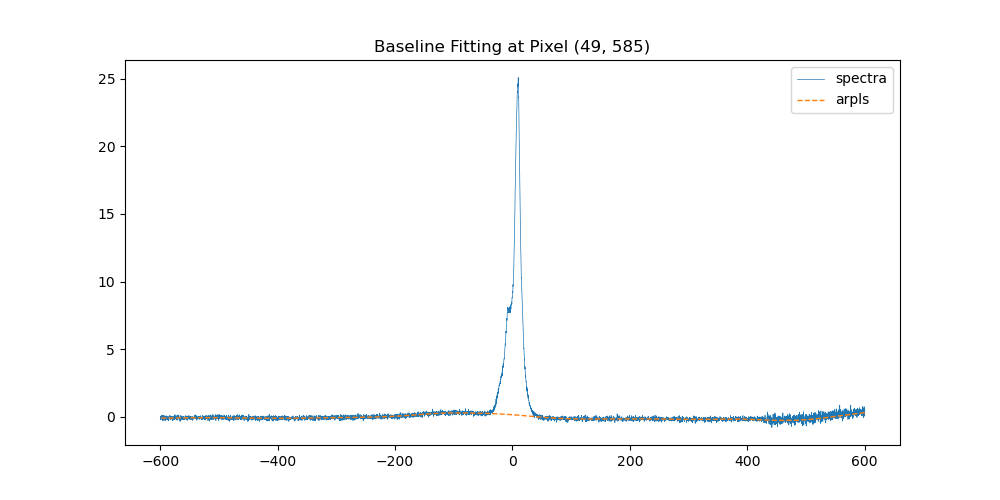

In [25]:
rng = np.random.default_rng()
y = rng.integers(1, n_y)
x = rng.integers(1, n_x)
spectra = data[:, y, x]

v_masked = velocities
spec_masked = spectra

baseline_fitter = Baseline(x_data=velocities)
baseline, params = baseline_fitter.arpls(spec_masked, lam=1e8)

fig = plt.figure(figsize=(10, 5))
plt.plot(velocities, spectra, label="spectra", lw=0.5)
plt.plot(velocities, baseline, "--", label="arpls", lw=1)
plt.title(f"Baseline Fitting at Pixel ({x}, {y})")
plt.legend()
plt.show()

In [26]:
baseline_fitter = Baseline(x_data=velocities)
dataset = data.transpose(1, 2, 0).reshape(n_y * n_x, n_v)
baselines = np.empty_like(dataset)
partial_func = partial(baseline_fitter.arpls, lam=1e8)

# 使用joblib并行计算，并将结果填充到baselines数组中
for i, (baseline, params) in enumerate(
    Parallel(n_jobs=-1, backend="loky", return_as="generator")(
        delayed(partial_func)(dataset[i]) for i in trange(len(dataset))
    )
):
    baselines[i] = baseline

  0%|          | 0/480000 [00:00<?, ?it/s]

In [27]:
baselines_data = baselines.T.reshape(n_v, n_y, n_x)
corrected_data = data - baselines_data
corrected_data *= u.K
corrected_cube = sc(data=corrected_data, wcs=cube.wcs)

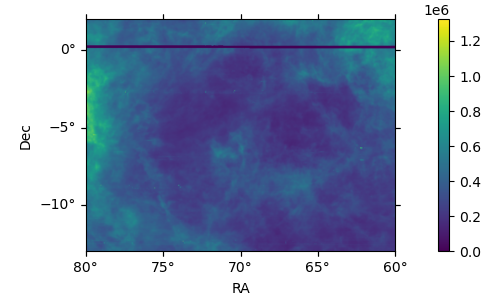

SpectralCube with shape=(995, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:    60.012500 deg:   79.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:    995  type_s: VRAD      unit_s: m / s  range:  -255098.374 m / s:  -55022.481 m / s
SpectralCube with shape=(994, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:    60.012500 deg:   79.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:    994  type_s: VRAD      unit_s: m / s  range:    83058.065 m / s:  282932.675 m / s


In [28]:
def displayimage(cube, region=None):
    img = cube.moment(order=0).value  # moment 0
    fig, ax = plt.subplots(
        figsize=(5, 3),
        layout="compressed",
        subplot_kw={"projection": cube.wcs.celestial},
    )
    norm = simple_norm(np.array(img), vmin=0, vmax=np.max(img), stretch="linear")
    im = ax.imshow(img, norm=norm, cmap="viridis", origin="lower")
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter("dd")
    lat.set_major_formatter("dd")
    lon.set_axislabel("RA")
    lat.set_axislabel("Dec")
    if region != None:
        region.plot(color="white")
    plt.colorbar(im)
    plt.show()


# Display the corrected cube
corrected_cube_minus = corrected_cube.spectral_slab(velocity_minus[ra_i,0] * u.km / u.s, velocity_minus[ra_i,1] * u.km / u.s)
corrected_cube_plus = corrected_cube.spectral_slab(velocity_plus[ra_i,0] * u.km / u.s, velocity_plus[ra_i,1] * u.km / u.s)
displayimage(corrected_cube)
print(corrected_cube_minus)
print(corrected_cube_plus)

In [29]:
# Save the corrected cube to a new FITS file
corrected_cube.write(corrected_file, overwrite=True)
corrected_cube_minus.write(corrected_file_minus, overwrite=True)
corrected_cube_plus.write(corrected_file_plus, overwrite=True)